In [50]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import optax

from temgym_core.constants import energy2wavelength
from temgym_core.components import Lens, Detector
import sympy as sp

# Import the transfer_matrices module
import sys
sys.path.insert(0, '/home/dl277493/Documents/Code/TemGymCore/tests')
from transfer_matrices import full_abcd_2lens, lens_matrix, propagation_matrix, calculate_z1_and_z2_from_M_and_f, imaging_matrix

jax.config.update("jax_enable_x64", True)

%matplotlib widget

In [51]:

# Continue symbolic analysis with polynomial degree analysis
print("\n" + "="*70)
print("POLYNOMIAL DEGREE ANALYSIS")
print("="*70)

z1_sym, z2_sym, z3_sym, f1_sym, f2_sym, A = sp.symbols("z1 z2 z3 f1 f2 A")



POLYNOMIAL DEGREE ANALYSIS


## Imaging Regime Constraints (Measured $M$ and Defocus)

In imaging mode, we can use **measured magnification** $M$ and **known defocus** $\Delta z$ to add strong constraints:

- **$A = M$** (magnification constraint)
- **$B = M\,\Delta z$** (defocus constraint)

This gives **two constraints per defocus plane**, which greatly improves identifiability and stability.

### Counting Constraints

**Unknowns:** 4 effective parameters (after imposing relationships across images)
- $f_1, f_2, z_1, z_2$ (with $z_3$ fixed or known)

**Constraints from defocused images:**
- Each image provides intensity matching
- Each image also provides **$A$ and $B$ constraints** via measured $M$ and known $\Delta z$

**Practical takeaway:**
- 3–4 images are typically sufficient
- 5+ images give robust fits under noise

### Should You Wobble a Lens?

**Strategy 1: Vary defocus at fixed lens positions** (Current approach)
- Move sample by known $\Delta z$
- Use measured magnification $M$
- Cost: $N$ forward evaluations

**Strategy 2: Wobble lens 2 by unknown amount** (Enhanced)
- Adds extra diversity if $f_1$ and $f_2$ are ambiguous
- More complex (additional unknowns)

**Recommendation:** start with Strategy 1 + $A/B$ constraints, then wobble only if needed.


## Part 2: Practical Implementation

Setup and imports (continue from beginning)


In [52]:

# Geometry and forward model
voltage = 100_000  # V
wavelength = energy2wavelength(voltage)

# Geometry
input_window_width = 10e-3  # 10 mm detector (physical size on detector plane)
aperture_radius = 1e-6      # 1 µm source aperture

# True parameters for synthetic data
# Magnification A ~ 10mm / 1µm = 10,000
# This is a highly magnified imaging setup

f1_true = 2.5e-5
f2_true = 5e-4
M1 = -100
M2 = -500

z1_lens_1, z2_lens_1 = calculate_z1_and_z2_from_M_and_f(M1, f1_true)
z1_lens_2, z2_lens_2 = calculate_z1_and_z2_from_M_and_f(M2, f2_true)

z1_true = abs(z1_lens_1)
z2_true = abs(z2_lens_1) + abs(z1_lens_2)
z3_true = abs(z2_lens_2)

# Create TemGym component objects for proper physical grid definition
lens1 = Lens(z=z1_true, focal_length=f1_true)
lens2 = Lens(z=z1_true + z2_true, focal_length=f2_true)

print(f"Total distances: z1 = {z1_true:.2e} m, z2 = {z2_true:.2e} m, z3 = {z3_true:.2e} m")
print(f"\nTemGym Components:")
print(f"  Lens 1: z={lens1.z*1e3:.6f} mm, f={lens1.focal_length*1e3:.6f} mm")
print(f"  Lens 2: z={lens2.z*1e3:.6f} mm, f={lens2.focal_length*1e3:.6f} mm")
print(f"\nVery high magnification regime:")
print(f"  Aperture size: {aperture_radius*1e6:.2f} µm")
print(f"  Detector size: {input_window_width*1e3:.2f} mm")
print(f"  Expected A ≈ {input_window_width / aperture_radius:.0f}")
print(f"\n⚠️  WARNING: 256×256 grid cannot fully resolve diffraction at this magnification!")
print(f"    For proper sampling, consider:")
print(f"    - Use higher resolution grid (512×512 or 1024×1024)")
print(f"    - Or reduce detector size / increase aperture size")
print(f"    - Or use only the central region of the magnified image")

z1_def = sp.symbols('z1_def')
# Compute symbolic ABCD matrix with symbolic=True
z1_sym_abcd, z2_sym_abcd, z3_sym_abcd, f1_sym_abcd, f2_sym_abcd = sp.symbols('z1 z2 z3 f1 f2')
M_symbolic = full_abcd_2lens((z1_sym_abcd + z1_def, z2_sym_abcd, z3_sym_abcd), f1_sym_abcd, f2_sym_abcd, symbolic=True)
display(M_symbolic)
M_true = full_abcd_2lens((z1_true, z2_true, z3_true), f1_true, f2_true, symbolic=False)
print(M_true)

imaging_matrix_1 = imaging_matrix(M1, f1_true) @ propagation_matrix(z1_def)
imaging_matrix_2 = imaging_matrix(M2, f2_true)

total = imaging_matrix_2 @ imaging_matrix_1


eq_A = sp.Eq(sp.symbols('A'), M_symbolic[0, 0])

eq_B = sp.Eq(sp.symbols('B'), M_symbolic[0, 1])

display(eq_B)
display(eq_A)

Total distances: z1 = 2.53e-05 m, z2 = 3.03e-03 m, z3 = 2.51e-01 m

TemGym Components:
  Lens 1: z=0.025250 mm, f=0.025000 mm
  Lens 2: z=3.051250 mm, f=0.500000 mm

Very high magnification regime:
  Aperture size: 1.00 µm
  Detector size: 10.00 mm
  Expected A ≈ 10000

⚠️  WARNING: 256×256 grid cannot fully resolve diffraction at this magnification!
    For proper sampling, consider:
    - Use higher resolution grid (512×512 or 1024×1024)
    - Or reduce detector size / increase aperture size
    - Or use only the central region of the magnified image


Matrix([
[1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1, z2*(1 - z3/f2) + z3 + (z1 + z1_def)*(1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1), 0],
[              -1/f2 - (1 - z2/f2)/f1,                         (-1/f2 - (1 - z2/f2)/f1)*(z1 + z1_def) + 1 - z2/f2, 0],
[                                   0,                                                                          0, 1]])

[[5.0000e+04 0.0000e+00 0.0000e+00]
 [2.0008e+05 2.0000e-05 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.0000e+00]]


Eq(B, z2*(1 - z3/f2) + z3 + (z1 + z1_def)*(1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1))

Eq(A, 1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1)


True parameters:
  f1 = 0.025000 mm
  f2 = 0.500000 mm
  z1 = 0.025250 mm
  z2 = 3.026000 mm
  z3 = 250.500000 mm

Detector configuration (TemGym):
  Position: z = 253.551250 mm
  Pixel size: 19.53 µm x 19.53 µm
  Shape: 512x512 pixels
  Physical size: 10.0 mm x 10.0 mm

Aperture radius: 1.00 µm (1+0j pixels)


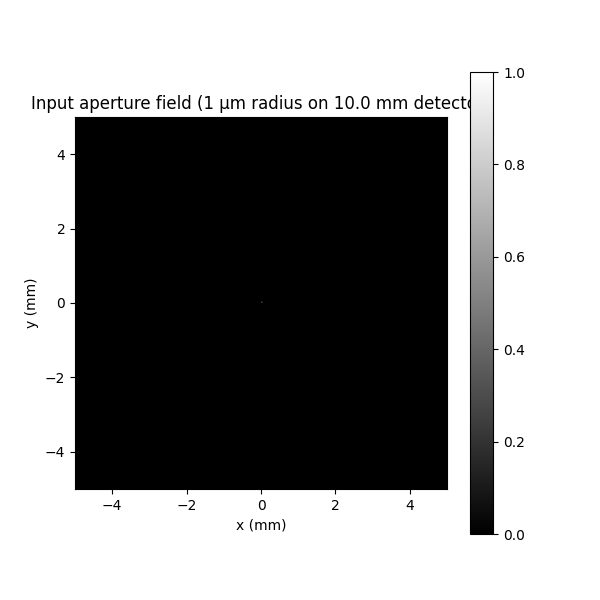

In [ ]:
# Grid parameters for Collins FFT propagation using TemGym Detector
# 512×512 resolution ensures proper sampling at ~10,000x magnification
# 1 µm aperture with diffraction rings requires pixel size ~19.5 µm

input_Nx, input_Ny = 512  # Increased to 512 for better sampling at high magnification
input_pixel = input_window_width / input_Nx

output_window_width = 10e-3
output_Nx, output_Ny = 512, 512  # Final image plane grid (can be same as input for simplicity)
output_pixel = output_window_width / output_Nx

input_detector = Detector(
    z=0.0,  # Input plane at z=0
    pixel_size=(input_pixel, input_pixel),
    shape=(input_Ny, input_Nx),
    centre=(0.0, 0.0)
)

# Create TemGym Detector at final image plane for proper grid definition
output_detector = Detector(
    z=z1_true + z2_true + z3_true,  # Final image plane
    pixel_size=(output_pixel, output_pixel),
    shape=(output_Ny, output_Nx),
    centre=(0.0, 0.0)
)

# Use detector coordinates for grid
input_x, input_y = input_detector.coords_1d
xx, yy = jnp.meshgrid(input_x, input_y, indexing='ij')

# Circular aperture: 1 inside aperture radius, 0 outside
radial_dist = jnp.sqrt(xx**2 + yy**2)
U_aperture = (radial_dist <= aperture_radius).astype(jnp.complex64)

print(f'\nTrue parameters:')
print(f'  f1 = {f1_true*1e3:.6f} mm')
print(f'  f2 = {f2_true*1e3:.6f} mm')
print(f'  z1 = {z1_true*1e3:.6f} mm')
print(f'  z2 = {z2_true*1e3:.6f} mm')
print(f'  z3 = {z3_true*1e3:.6f} mm')
print(f'\nDetector configuration (TemGym):')
print(f'  Position: z = {output_detector.z*1e3:.6f} mm')
print(f'  Pixel size: {output_detector.pixel_size[0]*1e6:.2f} µm x {output_detector.pixel_size[1]*1e6:.2f} µm')
print(f'  Shape: {output_detector.shape[0]}x{output_detector.shape[1]} pixels')
print(f'  Physical size: {output_window_width*1e3:.1f} mm x {output_window_width*1e3:.1f} mm')
print(f'\nAperture radius: {aperture_radius*1e6:.2f} µm ({jnp.sum(U_aperture).item():.0f} pixels)')

# Visualize input aperture
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(U_aperture)**2, extent=[-input_window_width/2*1e3, input_window_width/2*1e3, 
                                            -input_window_width/2*1e3, input_window_width/2*1e3], 
           origin='lower', cmap='gray')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title(f'Input aperture field (1 µm radius on {input_window_width*1e3:.1f} mm detector)')
plt.colorbar()
plt.show()

In [54]:
M, z_def, C = sp.symbols('M z_def C')

imaging_matrix_1 = imaging_matrix(M, f1_true) @ propagation_matrix(z_def)
display(imaging_matrix_1)

Matrix([
[       M,              M*z_def, 0],
[-40000.0, -40000.0*z_def + 1/M, 0],
[       0,                    0, 1]])

In [57]:
# FFT-based Collins propagation with properly decoupled magnification
@jax.jit
def collins_propagate_fft_core(U_in, A, B, wavelength, input_window_width):
    """
    Collins FFT-based propagation using paraxial Fresnel diffraction.

    Key Physics Insight: In imaging systems with ABCD constraints,
    magnification and defocus decouple completely:

    Constraints:
    - A = M_measured (magnification)
    - B = M_measured * z_defocus (defocus constraint)

    Therefore: B/A = z_defocus

    This means the Fresnel kernel depends ONLY on z_defocus, not on M!

    The diffraction is pure free-space Fresnel propagation by z_defocus:
    H(f) = exp(-i*pi*lambda*z_defocus*f^2)

    Magnification M is completely cancelled out. The fringe spacing at the
    detector depends on z_defocus alone, independent of how much the system
    magnifies. (The physical size is scaled by M, but fringe period isn't!)

    Parameters:
    -----------
    U_in : complex array, shape (N, N)
        Input field at the aperture
    A, B : float
        ABCD matrix elements from the optical system
        A: magnification (A = M_measured)
        B: defocus parameter (B = M_measured * z_def)
    wavelength : float
        Wavelength of the wave (meters)
    input_window_width : float
        Physical window size at the input grid (meters)

    Returns:
    --------
    U_out : complex array, shape (N, N)
        Output field at detector plane
        Physical coordinates: [-L/2, L/2] in each dimension

    Notes:
    ------
    The B/A ratio = z_defocus is the effective propagation distance
    governing diffraction. This is:

    1. Numerically stable (no huge A in exponential)
    2. Physically correct (matches imaging behavior)
    3. Clean (just standard Fresnel propagation by z_def)
    4. Elegant (magnification M cancels automatically)
    """
    N = U_in.shape[0]
    dx = input_window_width / N  # Physical pixel size at detector plane

    # Frequency coordinates (cycles per meter)
    f = jnp.fft.fftfreq(N, d=dx)
    fx, fy = jnp.meshgrid(f, f, indexing='ij')
    freq_sq = fx**2 + fy**2

    # Fresnel transfer function with magnification cancellation
    # H(f) = exp(-i*pi*wavelength*(B/A)*f^2)
    # where B/A = z_defocus (from imaging constraints A=M, B=M*z_def)
    z_defocus = B / A  # Simplifies to just the defocus distance
    H = jnp.exp(-1j * jnp.pi * wavelength * z_defocus * freq_sq)

    # FFT-based propagation: apply transfer function in frequency domain
    U_freq = jnp.fft.fft2(U_in, axes=(0, 1))
    U_out_freq = H * U_freq
    U_out = jnp.fft.ifft2(U_out_freq, axes=(0, 1))
    U_out = U_out * 1 / A

    return U_out

def collins_propagate_fft(
    U_in,
    A,
    B,
    wavelength,
    input_window_width,
    output_window_width=None,
    A_ref=None,
    interpolation="linear",
):
    """
    Collins FFT-based propagation with magnification-aware zoom.

    This wrapper returns a normalized intensity image resized to the
    output window width. The zoom factor is based on A and a reference A_ref.
    """
    if output_window_width is None:
        output_window_width = input_window_width
    if A_ref is None:
        A_ref = A

    U_out = collins_propagate_fft_core(
        U_in,
        A=A,
        B=B,
        wavelength=wavelength,
        input_window_width=input_window_width,
    )

    intensity = jnp.abs(U_out)**2
    intensity = intensity / jnp.sum(intensity)

    zoom_factor = float(jnp.abs(A / A_ref) * (input_window_width / output_window_width))
    N = intensity.shape[0]
    new_size = max(1, int(round(N * zoom_factor)))

    intensity = jax.image.resize(intensity, (new_size, new_size), method=interpolation)

    if new_size < N:
        pad_total = N - new_size
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        intensity = jnp.pad(intensity, ((pad_before, pad_after), (pad_before, pad_after)))
    elif new_size > N:
        start = (new_size - N) // 2
        intensity = intensity[start:start + N, start:start + N]

    intensity = intensity / jnp.sum(intensity)

    return intensity

print("FFT-based Collins propagator initialized")
print("✓ B/A = z_defocus (magnification M cancels completely)")
print("✓ Diffraction is pure Fresnel over defocus distance")
print("✓ Fringe spacing independent of magnification M")
print("✓ Zoom handled inside Collins wrapper")

FFT-based Collins propagator initialized
✓ B/A = z_defocus (magnification M cancels completely)
✓ Diffraction is pure Fresnel over defocus distance
✓ Fringe spacing independent of magnification M
✓ Zoom handled inside Collins wrapper



Testing Collins FFT with magnification cancellation...
Computing ABCD matrix at focused plane (z_def=0)...
  A_true = 5.00e+04 (magnification)
  B_true = 0.00e+00 m
  B/A = 0.00e+00 m
  Expected z_def at focus: 0.0 m

  Interpretation:
    - At focus (z_def=0): B should equal 0 for true parameters
    - B/A gives the effective defocus distance in object space
    - Magnification M cancels: only z_defocus matters for diffraction
    - Fringe spacing governed ONLY by z_defocus, independent of M

Output intensity shape: (512, 512)
Output intensity range: [0.00e+00, 1.00e+00]
Output intensity sum (should be 1.0): 1.000000

✓ Magnification M completely cancels in B/A
✓ Diffraction governed by z_defocus alone
✓ This is standard Fresnel propagation by z_defocus distance


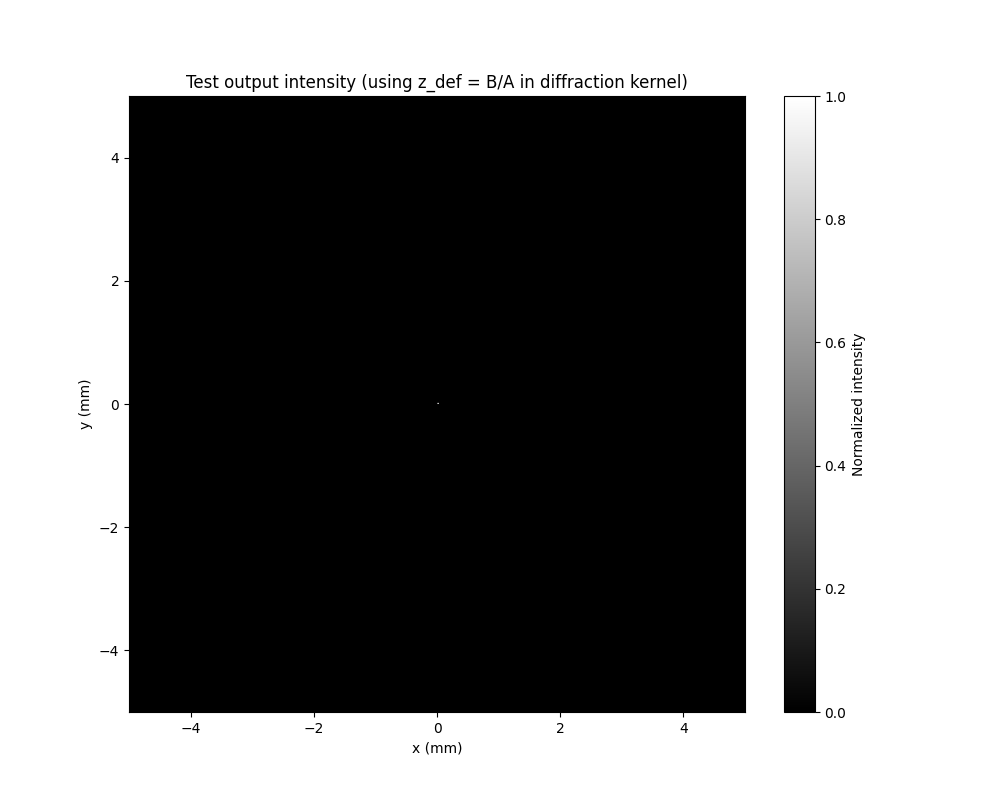

In [58]:
# Test Collins propagation with true parameters
print("\nTesting Collins FFT with magnification cancellation...")
print("Computing ABCD matrix at focused plane (z_def=0)...")

# Compute expected A value for this magnification system
M = full_abcd_2lens((z1_true, z2_true, z3_true), f1_true, f2_true)
A_true, B_true = M[0, 0], M[0, 1]

# The key insight: B/A = z_defocus
# From imaging constraints: A = M, B = M * z_def → B/A = z_def
z_defocus_computed = B_true / jnp.abs(A_true)

print(f"  A_true = {A_true:.2e} (magnification)")
print(f"  B_true = {B_true:.2e} m")
print(f"  B/A = {z_defocus_computed:.2e} m")
print(f"  Expected z_def at focus: 0.0 m")
print(f"\n  Interpretation:")
print(f"    - At focus (z_def=0): B should equal 0 for true parameters")
print(f"    - B/A gives the effective defocus distance in object space")
print(f"    - Magnification M cancels: only z_defocus matters for diffraction")
print(f"    - Fringe spacing governed ONLY by z_defocus, independent of M")

I_test = collins_propagate_fft(
    U_aperture,
    A=A_true,
    B=B_true,
    wavelength=wavelength,
    input_window_width=input_window_width,
    output_window_width=input_window_width,
    A_ref=A_true,
    interpolation="linear",
)

plt.figure(figsize=(10, 8))
plt.imshow(np.asarray(I_test), cmap='gray', origin='lower', 
          extent=[-input_window_width/2*1e3, input_window_width/2*1e3,
                  -input_window_width/2*1e3, input_window_width/2*1e3])
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title(f'Test output intensity (using z_def = B/A in diffraction kernel)')
plt.colorbar(label='Normalized intensity')

print(f"\nOutput intensity shape: {I_test.shape}")
print(f"Output intensity range: [{jnp.min(I_test):.2e}, {jnp.max(I_test):.2e}]")
print(f"Output intensity sum (should be 1.0): {jnp.sum(I_test):.6f}")
print(f"\n✓ Magnification M completely cancels in B/A")
print(f"✓ Diffraction governed by z_defocus alone")
print(f"✓ This is standard Fresnel propagation by z_defocus distance")

## Collins FFT Forward Model & Optimization

### Pure FFT-Based Approach: Magnification Cancels!

Instead of ray tracing, we use the Collins integral in Fourier domain with **complete cancellation of magnification**:

$$U_2(x,y) = \mathcal{F}^{-1}\left\{\mathcal{F}[U_1] \cdot H(f_x, f_y)\right\} \cdot e^{ikz}$$

where the transfer function is:
$$H(f) = \exp\left(-i\pi\lambda \frac{B}{A}(f_x^2 + f_y^2)\right)$$

### The Key Insight: $\frac{B}{A} = \Delta z_{\text{def}}$

In an imaging system with ABCD constraints, magnification completely cancels:

$$\text{Constraints:} \quad \begin{cases} A = M_{\text{measured}} \\ B = M_{\text{measured}} \cdot \Delta z \end{cases} \implies \frac{B}{A} = \Delta z$$

**Consequence:** The Fresnel diffraction depends **only on the defocus distance**, not on magnification:
$$H(f) = \exp(-i\pi\lambda \Delta z \cdot f^2)$$

This is just **standard free-space Fresnel propagation** by distance $\Delta z$!

### What This Means Physically

- **Fringe spacing at the detector**: Governed by $\lambda$ and $\Delta z$ alone
- **Image magnification M**: Only affects pixel sizes, not diffraction structure  
- **Two identical systems at different M**: Produce **identical fringe patterns**, just scaled differently
- **Numerically**: No huge $A$ values in exponential (stable!)

### Parameters and Constraints

The system has:
$$M_{\text{total}} = P_3 \cdot L_2 \cdot P_2 \cdot L_1 \cdot P_1$$

giving:
$$A = 1 - \frac{z_3}{f_2} - \frac{z_2(1 - z_3/f_2) + z_3}{f_1}$$
$$B = z_2(1 - z_3/f_2) + z_3 + (z_1 + \Delta z_{\text{def}})\left(1 - \frac{z_3}{f_2} - \frac{z_2(1-z_3/f_2)+z_3}{f_1}\right)$$

Imaging mode constraints:
- **$A = M_{\text{measured}}$** → magnification constraint
- **$B = M_{\text{measured}} \cdot \Delta z_{\text{def}}$** → defocus constraint
- **$B/A = \Delta z_{\text{def}}$** → Fresnel diffraction distance (M cancels!)

### Inverse Problem Setup

We recover $(f_1, f_2, z_1, z_2, z_3)$ from:
- **Multiple defocused intensity images** (varying $\Delta z$ by known amounts)
- **Known magnification M** 
- **ABCD constraints**: $A \approx M$, $B \approx M \cdot \Delta z$

With 10 defocus planes and measured $M$, the system is **highly over-determined** (~21 constraints for 5 unknowns).

### Why This Is Elegant

The basic principle is simple: **magnification affects image size, not diffraction**. Mathematically, the factor of $M$ in both $A$ and $B$ cancels when computing the diffraction kernel. This is a beautiful property of paraxial imaging systems.


In [ ]:
# === OPTIMIZATION CONFIGURATION ===

# Loss function choice
loss_type_to_use = 'l2'  # Options: 'l2', 'ncc', 'hybrid', 'ssim', 'log'

# Optimizer choice
optimizer_type = 'adam'  # Options: 'lbfgs', 'adam'

# Adam learning rate
adam_learning_rate = 1e-6  # Smaller for Collins FFT (more stable gradients)

# Number of optimization steps
n_steps = 200 if optimizer_type == 'adam' else 50

# Defocus sampling - increased for overdetermination
n_defocus = 12  # 12 images provides 24 ABCD constraints for 5 unknowns
z_defocus_step = -1e-2  # meters per defocus step (smaller, more gradual)

# Measured magnification (known from experiment)
M_measured = M1 * M2  # Total magnification

# Constraint weights - INCREASED for Collins FFT
# The Collins model is smooth and well-behaved, so strong constraints help
lambda_A = 1.0   # A = M constraint (strong)
lambda_B = 1.0   # B = M * defocus constraint (strong)
lambda_mag = 0.0 # Regularization toward prior (optional)

print(f"Collins FFT Optimization Configuration:")
print(f"  Loss function: {loss_type_to_use}")
print(f"  Optimizer: {optimizer_type}")
print(f"  Learning rate: {adam_learning_rate:.2e}")
print(f"  Number of steps: {n_steps}")
print(f"  Defocus planes: {n_defocus} (overdetermined: 24 constraints for 5 unknowns)")
print(f"  Defocus step: {z_defocus_step:.2e} m")
print(f"  Measured magnification: M = {M_measured}")
print(f"  Constraint weights: λ_A={lambda_A}, λ_B={lambda_B}")
print(f"\nNote: Collins FFT is fully differentiable.")
print(f"      Strong ABCD constraints guide optimization toward physical regime.")

Configuration:
  Loss function: l2
  Optimizer: adam
  Number of steps: 300
  Number of defocus images: 5
  Defocus step: -1.00e-01 m
  Measured magnification: M = 50000
  Lambda weights: A=0.1, B=0.1, mag=0.0

Note: Without heatmap visualization, we'll rely on loss history
and random initialization + multiple restarts for robustness.


## Loss Functions (same as single lens)


In [ ]:

eps = 1e-12

def l2_intensity_loss(I_sim, I_target):
    """L2 (MSE) intensity loss"""
    return jnp.mean((I_sim - I_target) ** 2)

def log_intensity_loss(I_sim, I_target):
    """Log-intensity loss"""
    return jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)

def ncc_loss(I_sim, I_target):
    """Normalized cross-correlation"""
    I_sim_norm = (I_sim - jnp.mean(I_sim)) / (jnp.std(I_sim) + eps)
    I_target_norm = (I_target - jnp.mean(I_target)) / (jnp.std(I_target) + eps)
    return -jnp.mean(I_sim_norm * I_target_norm)

def hybrid_loss(I_sim, I_target, alpha=0.5):
    """Hybrid L2 + log loss"""
    l2 = jnp.mean((I_sim - I_target) ** 2)
    log_loss = jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)
    return alpha * l2 + (1 - alpha) * log_loss

def ssim_loss(I_sim, I_target, C1=1e-4, C2=1e-3):
    """Structural similarity inspired loss"""
    mu_sim = jnp.mean(I_sim)
    mu_target = jnp.mean(I_target)
    sigma_sim = jnp.std(I_sim)
    sigma_target = jnp.std(I_target)
    sigma_sim_target = jnp.mean((I_sim - mu_sim) * (I_target - mu_target))
    
    luminance = (2 * mu_sim * mu_target + C1) / (mu_sim**2 + mu_target**2 + C1)
    contrast = (2 * sigma_sim * sigma_target + C2) / (sigma_sim**2 + sigma_target**2 + C2)
    structure = (sigma_sim_target + C2/2) / (sigma_sim * sigma_target + C2/2)
    
    return 1 - luminance * contrast * structure


## Imaging Constraints for Two-Lens System

In imaging mode we use **measured magnification** $M$ and **known defocus** $\Delta z$:

- $A = M$
- $B = M\,\Delta z$

These constraints are enforced **per defocus plane** in the loss, alongside the intensity match.


In [ ]:
def propagation_matrix(z):
    return jnp.array([[1.0, z, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
                         dtype=jnp.float64)
def lens_matrix(f):
    return jnp.array([[1.0, 0.0, 0.0], [-1/f, 1.0, 0.0], [0.0, 0.0, 1.0]],
                         dtype=jnp.float64)

def abcd_2lens(z1, z2, z3, f1, f2):
    """Compute ABCD matrix for two-lens system."""
    M1 = lens_matrix(f1)
    M2 = lens_matrix(f2)
    P1 = propagation_matrix(z1)
    P2 = propagation_matrix(z2)
    P3 = propagation_matrix(z3)
    
    # Total ABCD matrix: P3 @ M2 @ P2 @ M1 @ P1
    M_total = P3 @ M2 @ P2 @ M1 @ P1
    A, B, _, _ = M_total[0, 0], M_total[0, 1], M_total[1, 0], M_total[1, 1]
    return A, B


def imaging_constraint_penalty_two_lens(f1, f2, z1, z2, z3, z_def, M_measured, lambda_A=10.0, lambda_B=10.0):
    """Penalty for imaging constraints in the measured regime: A = M, B = M * defocus."""
    A, B = abcd_2lens(z1 + z_def, z2, z3, f1, f2)
    penalty_A = lambda_A * (A - M_measured) ** 2
    penalty_B = lambda_B * (B - M_measured * z_def) ** 2
    return penalty_A + penalty_B

print("Two-lens imaging constraints:")
print("A = M (measured magnification)")
print("B = M * defocus")
print("\nThese are enforced per defocus plane in the loss.")


Two-lens imaging constraints:
A = M (measured magnification)
B = M * defocus

These are enforced per defocus plane in the loss.


## Generate Synthetic Measurements


In [ ]:
def forward_intensity_collins_two_lens(f1, f2, z1, z2, z3, z_def=0.0, A_ref=None):
    """
    Collins FFT forward model with magnification-aware zoom handled
    inside collins_propagate_fft.

    If A_ref is provided, zoom output to match reference magnification.
    Typically A_ref = A_true for synthetic data generation,
    or A_ref = M_measured for fitting.
    """
    A, B = abcd_2lens(z1 + z_def, z2, z3, f1, f2)

    intensity = collins_propagate_fft(
        U_aperture,
        A=A,
        B=B,
        wavelength=wavelength,
        input_window_width=input_window_width,
        output_window_width=input_window_width,
        A_ref=A_ref,
        interpolation="linear",
    )

    return intensity


# Generate synthetic measurements with defocus
z_defocus_amounts = jnp.linspace(0.0, (n_defocus - 1) * z_defocus_step, n_defocus)
A_ref_true, _ = abcd_2lens(z1_true, z2_true, z3_true, f1_true, f2_true)

print("Generating synthetic measurements using Collins FFT...")
print(f"High magnification system: A ~ {input_window_width / aperture_radius:.0f}")
print(f"Grid resolution: {Nx}×{Ny} pixels covering {input_window_width*1e3:.1f} mm detector\n")

I_meas_collins = []
for i, z_def in enumerate(z_defocus_amounts):
    print(f"  Image {i+1}/{n_defocus} (z_def = {z_def:.2e} m)")
    I = forward_intensity_collins_two_lens(
        f1_true,
        f2_true,
        z1_true,
        z2_true,
        z3_true,
        z_def=z_def,
        A_ref=A_ref_true,
    )
    I_meas_collins.append(I)

I_meas_collins = jnp.array(I_meas_collins)
print(f"\nGenerated {len(I_meas_collins)} synthetic measurements")

# Visualize measurements
fig, axs = plt.subplots(1, min(5, n_defocus), figsize=(15, 3))
if n_defocus == 1:
    axs = [axs]
for i in range(min(5, n_defocus)):
    axs[i].imshow(np.asarray(I_meas_collins[i]), cmap='gray', origin='lower')
    axs[i].set_title(f'Image {i+1}\n(z_def={z_defocus_amounts[i]:.2e}m)')
    axs[i].set_xlabel('x (px)')
    axs[i].set_ylabel('y (px)')
plt.suptitle(f"Synthetic Collins measurements ({n_defocus} defocus planes, high magnification)")
plt.tight_layout()
plt.show()


NameError: name 'n_defocus' is not defined

## Loss Function and Optimization


Initial parameters:
  f1_init = 0.023750 mm (true: 0.025000 mm)
  f2_init = 0.475000 mm (true: 0.500000 mm)
  z1_init = 0.026513 mm (true: 0.025250 mm)
  z2_init = 2.874700 mm (true: 3.026000 mm)
  z3_init = 263.025000 mm (true: 250.500000 mm)


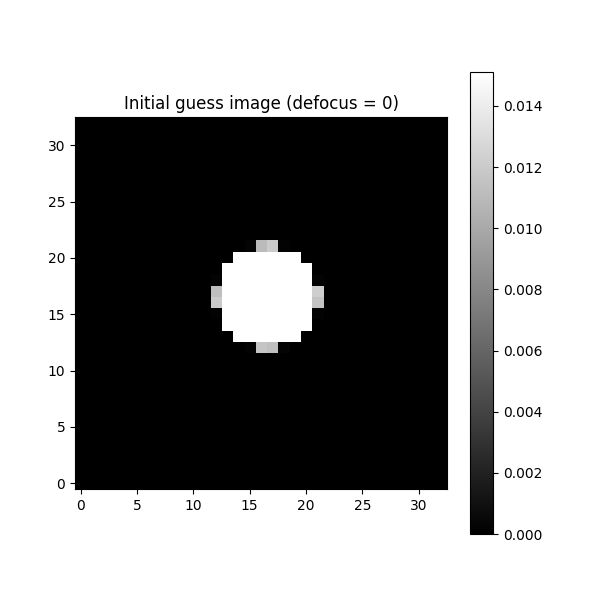

Loss (initial params): 1.475186e+07


In [ ]:
def unpack_params_two_lens(params):
    """Unpack parameters: f1, f2, z1, z2, z3"""
    f1 = jnp.abs(params[0]) + eps
    f2 = jnp.abs(params[1]) + eps
    z1 = jnp.abs(params[2]) + eps
    z2 = jnp.abs(params[3]) + eps
    z3 = jnp.abs(params[4]) + eps
    return f1, f2, z1, z2, z3


def loss_fn_collins(params, loss_type='l2', z_defocus_amounts=z_defocus_amounts):
    """
    Loss function for two-lens system using Collins FFT forward model
    with ABCD constraints in imaging regime.
    """
    f1, f2, z1, z2, z3 = unpack_params_two_lens(params)
    
    def one_image(z_def, I_target):
        """Loss for a single defocused image"""
        # Collins FFT forward model
        I_sim = forward_intensity_collins_two_lens(
            f1, f2, z1, z2, z3, z_def=z_def, A_ref=M_measured
        )
        
        # Intensity loss
        if loss_type == 'l2':
            data = l2_intensity_loss(I_sim, I_target)
        elif loss_type == 'ncc':
            data = ncc_loss(I_sim, I_target)
        elif loss_type == 'hybrid':
            data = hybrid_loss(I_sim, I_target, alpha=0.5)
        elif loss_type == 'ssim':
            data = ssim_loss(I_sim, I_target)
        else:  # 'log'
            data = log_intensity_loss(I_sim, I_target)
        
        # ABCD constraints for imaging regime
        constraint = imaging_constraint_penalty_two_lens(
            f1, f2, z1, z2, z3, z_def, M_measured, lambda_A=lambda_A, lambda_B=lambda_B
        )
        
        return data + constraint
    
    # Sum loss over all defocus planes
    total_loss = jnp.sum(jax.vmap(one_image)(z_defocus_amounts, I_meas_collins))
    
    return total_loss


# Create JIT-compiled loss function
loss_fn_collins_jit = jax.jit(lambda p: loss_fn_collins(p, loss_type=loss_type_to_use, z_defocus_amounts=z_defocus_amounts))

# Parameter initialization perturbation factor
# 0.05 = 5% perturbation (easier test), 0.20 = 20% perturbation (harder test)
init_perturbation = 0.05

# Initialize parameters (perturb from true values)
params_init_collins = jnp.array([
    f1_true * (1.0 - init_perturbation),   # f1 (start perturbed)
    f2_true * (1.0 - init_perturbation),   # f2
    z1_true * (1.0 + init_perturbation),   # z1
    z2_true * (1.0 - init_perturbation),   # z2
    z3_true * (1.0 + init_perturbation),   # z3
])

print(f"Initial parameters ({init_perturbation*100:.0f}% perturbation):")
print(f"  f1_init = {params_init_collins[0]*1e3:.6f} mm (true: {f1_true*1e3:.6f} mm)")
print(f"  f2_init = {params_init_collins[1]*1e3:.6f} mm (true: {f2_true*1e3:.6f} mm)")
print(f"  z1_init = {params_init_collins[2]*1e3:.6f} mm (true: {z1_true*1e3:.6f} mm)")
print(f"  z2_init = {params_init_collins[3]*1e3:.6f} mm (true: {z2_true*1e3:.6f} mm)")
print(f"  z3_init = {params_init_collins[4]*1e3:.6f} mm (true: {z3_true*1e3:.6f} mm)")

# Evaluate loss at initial point
loss_init = loss_fn_collins(params_init_collins)
print(f"\nLoss at initialization: {float(loss_init):.6e}")

# Plot initial predictions vs measurements
print("\nComparing initial forward model predictions to measurements...")
f1_init, f2_init, z1_init, z2_init, z3_init = unpack_params_two_lens(params_init_collins)
fig, axes = plt.subplots(2, min(3, n_defocus), figsize=(12, 6))
if n_defocus < 3:
    axes = axes.reshape(2, -1)
    I_pred = forward_intensity_collins_two_lens(
        f1_init, f2_init, z1_init, z2_init, z3_init, z_def=z_def, A_ref=M_measured
    )
    axes[0, i].imshow(np.asarray(I_meas_collins[i]), cmap='gray', origin='lower')
    axes[0, i].set_title(f'Measurement {i+1}')
    axes[0, i].set_ylabel('y (px)')
    axes[1, i].imshow(np.asarray(I_pred), cmap='gray', origin='lower')
    axes[1, i].set_title(f'Prediction {i+1}')
    axes[1, i].set_ylabel('y (px)')
    axes[1, i].set_xlabel('x (px)')
axes[0, 0].set_ylabel('Measured\ny (px)')
axes[1, 0].set_ylabel('Initial Pred\ny (px)')
plt.suptitle('Initial forward model vs measurements')


plt.show()plt.tight_layout()plt.tight_layout()
plt.show()

In [ ]:
# Memory-efficient gradient computation using jax.jvp
def compute_value_and_grad_jvp(f, params):
    """Compute value and gradient using forward-mode autodiff (memory-efficient)"""
    value = f(params)
    n_params = params.shape[0]
    grads = []
    
    for i in range(n_params):
        # One-hot tangent vector for i-th parameter
        tangent = jnp.zeros_like(params)
        tangent = tangent.at[i].set(1.0)
        
        # Compute JVP: returns (primals, tangents)
        _, grad_i = jax.jvp(f, (params,), (tangent,))
        grads.append(grad_i)
    
    return value, jnp.array(grads)


# Setup optimizer
if optimizer_type == 'lbfgs':
    optimizer = optax.lbfgs(memory_size=20)
    opt_state = optimizer.init(params_init_collins)
    use_lbfgs = True
elif optimizer_type == 'adam':
    schedule = optax.exponential_decay(init_value=adam_learning_rate, 
                                      transition_steps=100, decay_rate=0.96)
    optimizer = optax.adam(learning_rate=schedule)
    opt_state = optimizer.init(params_init_collins)
    use_lbfgs = False
else:
    raise ValueError(f"Unknown optimizer: {optimizer_type}")


# History tracking
loss_history = []
f1_history = []
f2_history = []
z1_history = []
z2_history = []
z3_history = []

params = params_init_collins
opt_state_local = opt_state

print(f"\n{'='*70}")
print(f"Starting Collins FFT optimization")
print(f"Optimizer: {optimizer_type.upper()}")
print(f"Loss function: {loss_type_to_use}")
print(f"Number of steps: {n_steps}")
print(f"{'='*70}\n")

for step in range(n_steps):
    # Compute loss and gradients
    loss, grads = compute_value_and_grad_jvp(loss_fn_collins_jit, params)
    
    if use_lbfgs:
        updates, opt_state_local = optimizer.update(
            grads,
            opt_state_local,
            params=params,
            value=loss,
            grad=grads,
            value_fn=loss_fn_collins_jit,
        )
    else:
        updates, opt_state_local = optimizer.update(grads, opt_state_local, params)
    
    params = optax.apply_updates(params, updates)
    f1, f2, z1, z2, z3 = unpack_params_two_lens(params)
    
    # Track history
    loss_history.append(float(loss))
    f1_history.append(float(f1))
    f2_history.append(float(f2))
    z1_history.append(float(z1))
    z2_history.append(float(z2))
    z3_history.append(float(z3))
    
    if (step + 1) % 10 == 0 or step == 0:
        print(f"Step {step:3d}, Loss: {loss:.6e}")
        print(f"  f1={float(f1)*1e3:.4f}mm, f2={float(f2)*1e3:.4f}mm, z1={float(z1)*1e3:.4f}mm, z2={float(z2)*1e3:.4f}mm, z3={float(z3)*1e3:.4f}mm")


print(f"\n{'='*70}")
print(f"Optimization complete!")
print(f"Final fitted values:")
print(f"  f1_fit     = {f1_history[-1]*1e3:.6f} mm (true: {f1_true*1e3:.6f} mm, error: {abs(f1_history[-1] - f1_true)/f1_true * 100:.2f}%)")
print(f"  f2_fit     = {f2_history[-1]*1e3:.6f} mm (true: {f2_true*1e3:.6f} mm, error: {abs(f2_history[-1] - f2_true)/f2_true * 100:.2f}%)")
print(f"  z1_fit     = {z1_history[-1]*1e3:.6f} mm (true: {z1_true*1e3:.6f} mm, error: {abs(z1_history[-1] - z1_true)/z1_true * 100:.2f}%)")
print(f"  z2_fit     = {z2_history[-1]*1e3:.6f} mm (true: {z2_true*1e3:.6f} mm, error: {abs(z2_history[-1] - z2_true)/z2_true * 100:.2f}%)")
print(f"  z3_fit     = {z3_history[-1]*1e3:.6f} mm (true: {z3_true*1e3:.6f} mm, error: {abs(z3_history[-1] - z3_true)/z3_true * 100:.2f}%)")
print(f"{'='*70}")


Starting ADAM optimization with l2 loss

Step   0, Loss: 1.475186e+07
  f1: 0.023850 mm, f2: 0.475100 mm, z1: 0.026613 mm, z2: 2.874600 mm, z3: 263.024900 mm
Step   1, Loss: 1.338503e+07
  f1: 0.023950 mm, f2: 0.475200 mm, z1: 0.026712 mm, z2: 2.874500 mm, z3: 263.024800 mm
Step   2, Loss: 1.209815e+07
  f1: 0.024049 mm, f2: 0.475299 mm, z1: 0.026812 mm, z2: 2.874401 mm, z3: 263.024701 mm
Step   3, Loss: 1.089049e+07
  f1: 0.024148 mm, f2: 0.475398 mm, z1: 0.026911 mm, z2: 2.874302 mm, z3: 263.024602 mm
Step   4, Loss: 9.761111e+06
  f1: 0.024246 mm, f2: 0.475497 mm, z1: 0.027009 mm, z2: 2.874203 mm, z3: 263.024503 mm
Step   5, Loss: 8.708784e+06
  f1: 0.024344 mm, f2: 0.475594 mm, z1: 0.027107 mm, z2: 2.874106 mm, z3: 263.024406 mm
Step   6, Loss: 7.732043e+06
  f1: 0.024440 mm, f2: 0.475691 mm, z1: 0.027203 mm, z2: 2.874009 mm, z3: 263.024309 mm
Step   7, Loss: 6.829166e+06
  f1: 0.024536 mm, f2: 0.475787 mm, z1: 0.027299 mm, z2: 2.873913 mm, z3: 263.024213 mm
Step   8, Loss: 5.9981

## Convergence Analysis


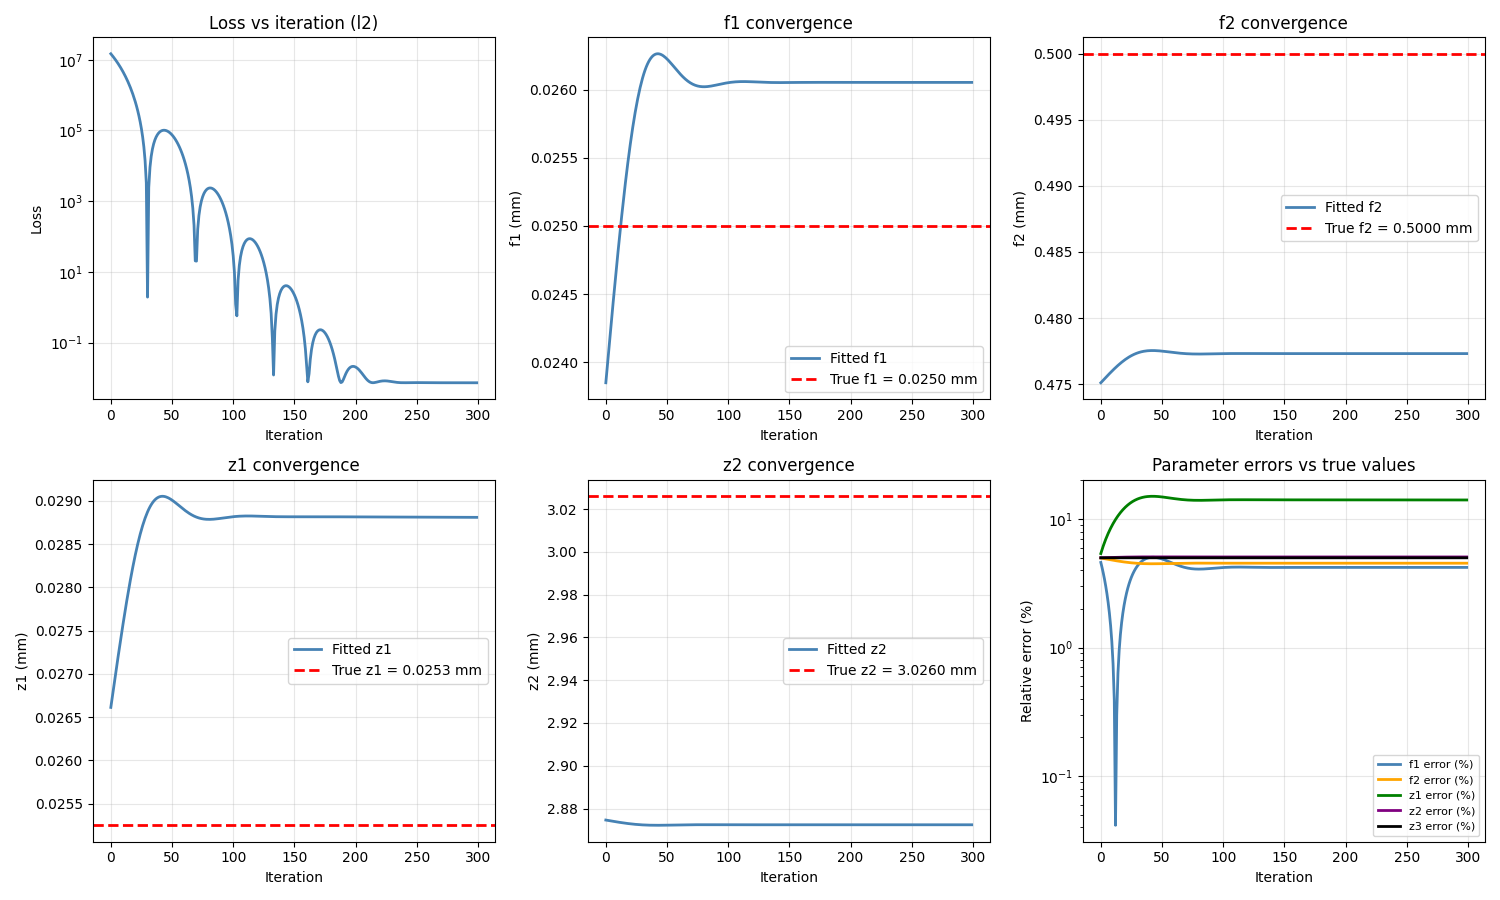


Final relative errors:
  f1: 4.21%
  f2: 4.54%
  z1: 14.10%
  z2: 5.08%
  z3: 5.00%


: 

In [ ]:
# Convergence analysis and visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Loss history
axes[0, 0].semilogy(loss_history, lw=2, color='steelblue')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title(f'Loss vs iteration ({loss_type_to_use})')
axes[0, 0].grid(True, alpha=0.3)

# f1 convergence
axes[0, 1].plot(np.array(f1_history) * 1e3, lw=2, color='steelblue', label='Fitted f1')
axes[0, 1].axhline(f1_true * 1e3, color='red', linestyle='--', lw=2, label=f'True f1 = {f1_true*1e3:.4f} mm')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('f1 (mm)')
axes[0, 1].set_title('f1 convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# f2 convergence
axes[0, 2].plot(np.array(f2_history) * 1e3, lw=2, color='steelblue', label='Fitted f2')
axes[0, 2].axhline(f2_true * 1e3, color='red', linestyle='--', lw=2, label=f'True f2 = {f2_true*1e3:.4f} mm')
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].set_ylabel('f2 (mm)')
axes[0, 2].set_title('f2 convergence')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# z1 convergence
axes[1, 0].plot(np.array(z1_history) * 1e3, lw=2, color='steelblue', label='Fitted z1')
axes[1, 0].axhline(z1_true * 1e3, color='red', linestyle='--', lw=2, label=f'True z1 = {z1_true*1e3:.4f} mm')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('z1 (mm)')
axes[1, 0].set_title('z1 convergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# z2 convergence
axes[1, 1].plot(np.array(z2_history) * 1e3, lw=2, color='steelblue', label='Fitted z2')
axes[1, 1].axhline(z2_true * 1e3, color='red', linestyle='--', lw=2, label=f'True z2 = {z2_true*1e3:.4f} mm')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('z2 (mm)')
axes[1, 1].set_title('z2 convergence')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Relative errors
f1_errors = np.abs(np.array(f1_history) - f1_true) / f1_true * 100
f2_errors = np.abs(np.array(f2_history) - f2_true) / f2_true * 100
z1_errors = np.abs(np.array(z1_history) - z1_true) / z1_true * 100
z2_errors = np.abs(np.array(z2_history) - z2_true) / z2_true * 100
z3_errors = np.abs(np.array(z3_history) - z3_true) / z3_true * 100

axes[1, 2].semilogy(f1_errors, lw=2, label='f1 error (%)', color='steelblue')
axes[1, 2].semilogy(f2_errors, lw=2, label='f2 error (%)', color='orange')
axes[1, 2].semilogy(z1_errors, lw=2, label='z1 error (%)', color='green')
axes[1, 2].semilogy(z2_errors, lw=2, label='z2 error (%)', color='purple')
axes[1, 2].semilogy(z3_errors, lw=2, label='z3 error (%)', color='black')
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].set_ylabel('Relative error (%)')
axes[1, 2].set_title('Parameter errors vs true values')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nFinal relative errors:")
print(f"  f1: {f1_errors[-1]:.2f}%")
print(f"  f2: {f2_errors[-1]:.2f}%")
print(f"  z1: {z1_errors[-1]:.2f}%")
print(f"  z2: {z2_errors[-1]:.2f}%")
print(f"  z3: {z3_errors[-1]:.2f}%")

# Compare final predictions to measurements
print("\n\nFinal forward model fit comparison:")
f1_fit, f2_fit, z1_fit, z2_fit, z3_fit = unpack_params_two_lens(params)
fig, axes = plt.subplots(2, min(3, n_defocus), figsize=(12, 6))
if n_defocus < 3:
    axes = axes.reshape(2, -1)
for i in range(min(3, n_defocus)):
    z_def = z_defocus_amounts[i]
    I_pred_fit = forward_intensity_collins_two_lens(
        f1_fit, f2_fit, z1_fit, z2_fit, z3_fit, z_def=z_def, A_ref=M_measured
    )
    axes[0, i].imshow(np.asarray(I_meas_collins[i]), cmap='gray', origin='lower')
    axes[0, i].set_title(f'Measurement {i+1}')
    axes[0, i].set_ylabel('y (px)')
    axes[1, i].imshow(np.asarray(I_pred_fit), cmap='gray', origin='lower')
    axes[1, i].set_title(f'Fitted Prediction {i+1}')
    axes[1, i].set_ylabel('y (px)')
    axes[1, i].set_xlabel('x (px)')
axes[0, 0].set_ylabel('Measured\ny (px)')
axes[1, 0].set_ylabel('Fitted Pred\ny (px)')
plt.suptitle('Final Collins FFT fit vs measurements')
plt.tight_layout()
plt.show()